# 18/08/2024 - Week 6
### Model Deployment

In [ ]:
# import libraries
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


In [ ]:
cancer_data = load_breast_cancer()
x=cancer_data.data
y=cancer_data.target

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=MLPClassifier(hidden_layer_sizes=(64,32),
                    max_iter=1000,
                    random_state=42,
                    activation='relu',
                    verbose=3)

In [ ]:
model.fit(x_train,y_train)

In [ ]:
model.score(x_test,y_test)

# Tensorflow Exercise

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

In [ ]:
# To load dataset from mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


In [ ]:
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)

In [ ]:
from collections import Counter

Counter(test_labels)

In [ ]:
# normalize the data to set it between 0 and 1

train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0

In [ ]:
# expand the features shape to (28,28,1)
import numpy as np
train_images=np.expand_dims(train_images,-1)
test_images=np.expand_dims(test_images,-1)

In [ ]:
train_labels = to_categorical(train_labels)
test_labels= to_categorical(test_labels)

In [ ]:
test_labels[0]

In [ ]:
# construct the model

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu',kernel_regularizer=l2(0.001)),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(10,activation='softmax')
])
print(model.summary())

In [ ]:
model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics =['accuracy'])

In [ ]:
history=model.fit(train_images,train_labels, batch_size=10, epochs= 15, validation_split=0.1)

In [ ]:
import matplotlib.pyplot as plt

# Plotting the accuracy
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
score = model.evaluate(test_images,test_labels, verbose=0)
print("Test loss", score[0])
print("Test Accuracy",score[1]) 

In [1]:
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.datasets import cifar10

# To load dataset from mnist
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()


2.17.0


In [2]:
print(train_images.shape)
print(test_images.shape)
print(train_labels.shape)
print(test_labels.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)


In [3]:
train_labels = to_categorical(train_labels)
test_labels= to_categorical(test_labels)

In [4]:
test_labels[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [5]:
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512,activation='relu'),
    Dense(512,activation='relu'),
    Dense(128,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])
print(model.summary())

model.compile(optimizer='adam',
              loss = 'categorical_crossentropy',
              metrics =['accuracy'])

c:\Users\Muhammad Afiq\anaconda3\envs\python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,927,114 (7.35 MB)

 Trainable params: 1,927,114 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
history=model.fit(train_images,train_labels, batch_size=128, epochs= 20, validation_split=0.1)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.1579 - loss: 50.1665 - val_accuracy: 0.2998 - val_loss: 2.0081
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.3139 - loss: 1.9748 - val_accuracy: 0.3322 - val_loss: 1.9133
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3596 - loss: 1.8290 - val_accuracy: 0.3094 - val_loss: 2.0082
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3722 - loss: 1.7866 - val_accuracy: 0.3822 - val_loss: 1.7574
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3892 - loss: 1.7286 - val_accuracy: 0.4018 - val_loss: 1.7079
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4060 - loss: 1.6725 - val_accuracy: 0.3652 - val_loss: 1.7810
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4083 - loss: 1.6714 - val_accuracy: 0.3938 - val_loss: 1.7391
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4213 - loss: 1.6393 - val_acc

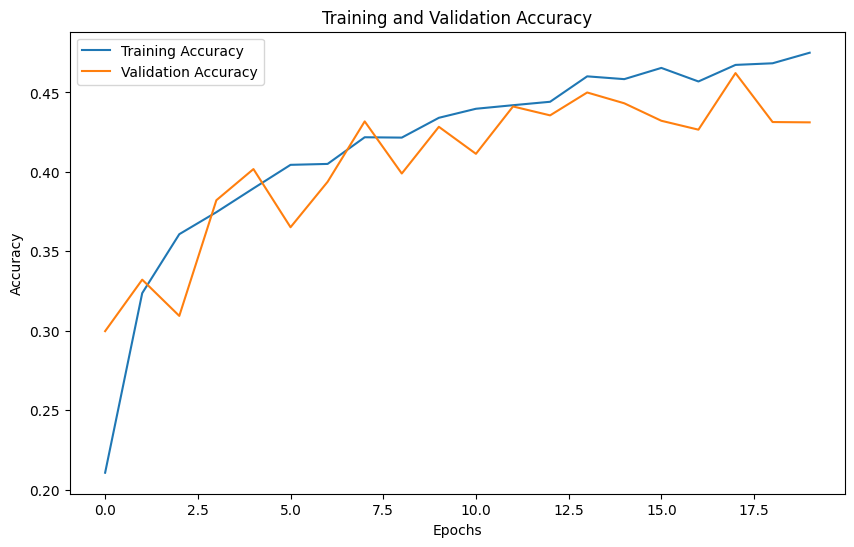

In [7]:
import matplotlib.pyplot as plt

# Plotting the accuracy
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [8]:
score = model.evaluate(test_images,test_labels, verbose=0)
print("Test loss", score[0])
print("Test Accuracy",score[1]) 

Test loss 1.584916591644287
Test Accuracy 0.4341000020503998
